# LIBRARY

In [2]:
"""%pip install scikit-plot -q
%pip install scipy -q"""

'%pip install scikit-plot -q\n%pip install scipy -q'

In [3]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
#from scikitplot.metrics import plot_roc
#from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT DATA SET 

In [5]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.000,50.8,932.498000,NaN,5.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.000,46.0,936.656000,70.0,NaN,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.500,75.6,1115.380000,94.0,5.0,...,1.0,25.512900,42.380000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.000,81.6,1131.430000,97.0,6.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,18.140416,54.626,77.0,1578.400000,NaN,NaN,...,2.0,31.506100,42.380000,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.229868,46.070,49.0,979.009933,82.5,2.5,...,1.0,19.336600,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,10.665793,56.130,47.8,1029.411546,80.5,5.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,13.509359,49.560,47.2,1034.387599,83.5,7.0,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,17.189894,63.790,99.5,1379.703447,87.5,NaN,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 30 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         8460 non-null   float64
 6   Physical-Weight                         8460 non-null   float64
 7   BIA-BIA_BMR                             8460 non-null   float64
 8   Physical-HeartRate                      7539 non-null   float64
 9   Fitness_Endurance-Max_Stage             5480 non-null   float64
 10  FGC-FGC_TL                              6945 non-null   floa

# Data Cleaning

## Removing useless variables

In [7]:
column2drop = ['id']
dfid=df.copy()
df.drop(column2drop, axis=1, inplace=True)

In [8]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,5,0,51.0,16.877316,46.000,50.8,932.498,NaN,5.0,6.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,9,0,NaN,14.035590,48.000,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,10,1,71.0,16.648696,56.500,75.6,1115.380,94.0,5.0,5.0,...,1.0,25.5129,42.3800,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,9,0,71.0,18.292347,56.000,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,18,1,65.0,18.140416,54.626,77.0,1578.400,NaN,NaN,10.0,...,2.0,31.5061,42.3800,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205


In [10]:
print(df.columns)

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')


# TARGET VARIABLES

## ** TARGET VARIABLE Physical-HeartRate

In [11]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [ ]:
df_HeartRate = df[[
        'Basic_Demos-Age',  
        'Physical-Height', 
        'Physical-Weight', 
        'Physical-HeartRate',
        'Physical-MAP_CAL',
        'BIA-BIA_DEE',
        #"BIA-BIA_Activity_Level_num",
        #'BIA-BIA_Frame_num',
        #'BIA-BIA_Fat'
       ]].copy()



In [13]:
df_HeartRate=df_HeartRate.dropna()

In [14]:
df_HeartRate.isnull().sum()

Basic_Demos-Age               0
Physical-Height               0
Physical-Weight               0
Physical-HeartRate            0
Physical-MAP_CAL              0
BIA-BIA_DEE                   0
BIA-BIA_Activity_Level_num    0
BIA-BIA_Frame_num             0
BIA-BIA_Fat                   0
dtype: int64

### Partitioning

In [15]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [17]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5654, 8) (1885, 8) (5654,) (1885,)


In [18]:
df_HeartRate.shape

(7539, 9)

### Randomized Search

In [19]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [20]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

In [21]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 150, 'max_depth': 18, 'criterion': 'friedman_mse'} -120.0581120031588


In [22]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=18,
                      min_samples_leaf=150, min_samples_split=0.05)

In [23]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 10.9113
MAE  : 8.1127
MSE  : 119.0571
R²   : 0.0653


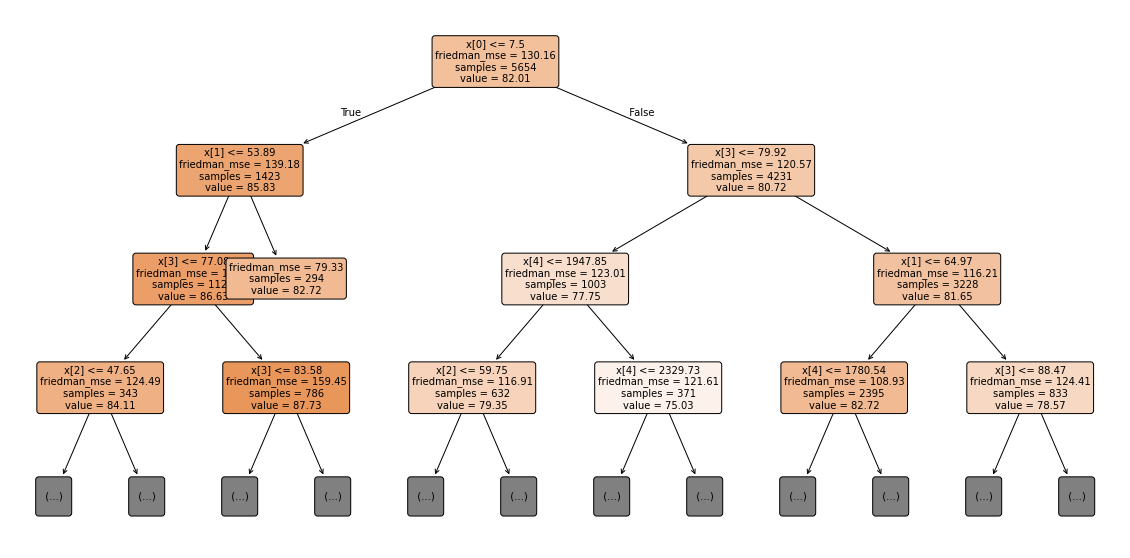

In [24]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_HeartRate,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1094 | 33.0000 |   79.0505 | 46.0505
1653 | 122.0000 |   81.6119 | 40.3881
1638 | 122.5000 |   82.2569 | 40.2431
 646 | 51.0000 |   90.6656 | 39.6656
1410 | 116.0000 |   76.9156 | 39.0844
 373 | 119.5000 |   80.6273 | 38.8727
 167 | 119.0000 |   80.6273 | 38.3727
1233 | 119.0000 |   81.7130 | 37.2870
1355 | 36.0000 |   73.2433 | 37.2433
 760 | 116.0000 |   79.0505 | 36.9495


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_967/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


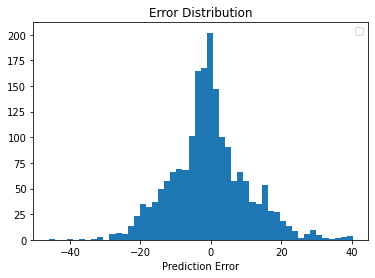

In [25]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [26]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.3291115104703128
Physical-MAP_CAL 0.2502239353380881
Physical-Height 0.1985026227944715
BIA-BIA_DEE 0.15722717509561204
Physical-Weight 0.044022935317404505
BIA-BIA_Fat 0.02091182098411103
BIA-BIA_Activity_Level_num 0.0
BIA-BIA_Frame_num 0.0


## ** TARGET VARIABLE CGAS-CGAS_Score'

In [27]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [28]:
df_CGAS_Score = df[[
'Basic_Demos-Age', 'Basic_Demos-Sex',
'CGAS-CGAS_Score', 
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Physical-Weight' , 'Physical-Height',
'BIA-BIA_DEE',
        "BIA-BIA_Activity_Level_num",
        'BIA-BIA_Frame_num',
        'BIA-BIA_Fat'     
       ]].copy()



In [29]:
df_CGAS_Score=df_CGAS_Score[(df_CGAS_Score['CGAS-CGAS_Score']<=100)&(round(df_CGAS_Score['CGAS-CGAS_Score'],0)!=65)]

In [30]:
df_CGAS_Score

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,FGC-FGC_CORE_CAL,Physical-Weight,Physical-Height,BIA-BIA_DEE,BIA-BIA_Activity_Level_num,BIA-BIA_Frame_num,BIA-BIA_Fat
0,5,0,51.0,16.877316,4.611111,50.8,46.00,1492.000000,2.0,1.0,9.213770
2,10,1,71.0,16.648696,27.000000,75.6,56.50,1796.890000,3.0,1.0,15.811750
3,9,0,71.0,18.292347,23.000000,81.6,56.00,1923.440000,3.0,2.0,18.824300
5,13,1,50.0,22.279952,18.000000,112.2,59.50,1996.450000,2.0,2.0,67.971500
11,11,0,66.0,17.894545,18.198142,77.0,55.00,1897.920000,3.0,1.0,15.811750
...,...,...,...,...,...,...,...,...,...,...,...
8452,6,1,65.5,11.558486,7.000000,48.8,54.48,1372.896460,3.0,1.0,10.213970
8456,10,1,69.5,10.665793,8.500000,47.8,56.13,1678.330810,3.0,1.0,7.651215
8457,10,1,70.0,13.509359,21.500000,47.2,49.56,1547.346725,4.0,2.0,15.626267
8458,15,1,55.5,17.189894,10.000000,99.5,63.79,1674.735823,2.0,2.0,26.718654


In [31]:
df_CGAS_Score.isnull().sum()

Basic_Demos-Age               0
Basic_Demos-Sex               0
CGAS-CGAS_Score               0
Physical-BMI                  0
FGC-FGC_CORE_CAL              0
Physical-Weight               0
Physical-Height               0
BIA-BIA_DEE                   0
BIA-BIA_Activity_Level_num    0
BIA-BIA_Frame_num             0
BIA-BIA_Fat                   0
dtype: int64

In [32]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [33]:
df_CGAS_Score.isnull().sum()

Basic_Demos-Age               0
Basic_Demos-Sex               0
CGAS-CGAS_Score               0
Physical-BMI                  0
FGC-FGC_CORE_CAL              0
Physical-Weight               0
Physical-Height               0
BIA-BIA_DEE                   0
BIA-BIA_Activity_Level_num    0
BIA-BIA_Frame_num             0
BIA-BIA_Fat                   0
dtype: int64

### Partitioning

In [34]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [36]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4445, 10) (1482, 10) (4445,) (1482,)


In [37]:
df_CGAS_Score.shape

(5927, 11)

### Randomized Search

In [38]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [39]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [40]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_CGAS_Score = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_CGAS_Score = random_search.best_estimator_

In [41]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 5, 'max_depth': 3, 'criterion': 'friedman_mse'} -105.69290344721885


In [42]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=3, min_samples_leaf=5,
                      min_samples_split=0.05)

In [43]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 10.0969
MAE  : 7.9551
MSE  : 101.9476
R²   : 0.0279


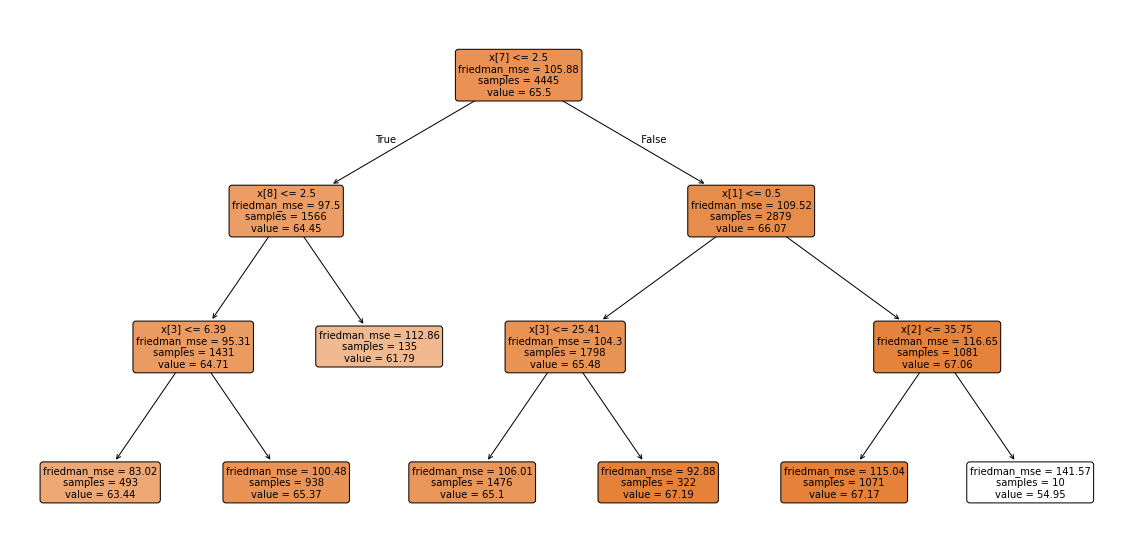

In [44]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_CGAS_Score,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  22 | 30.0000 |   67.1690 | 37.1690
 547 | 33.0000 |   67.1879 | 34.1879
 924 | 35.0000 |   67.1690 | 32.1690
 677 | 35.0000 |   65.1033 | 30.1033
1408 | 35.0000 |   65.1033 | 30.1033
 515 | 95.0000 |   67.1879 | 27.8121
 249 | 95.0000 |   67.1879 | 27.8121
 962 | 40.0000 |   67.1879 | 27.1879
 570 | 38.0000 |   65.1033 | 27.1033
 381 | 88.0000 |   61.7852 | 26.2148


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_967/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


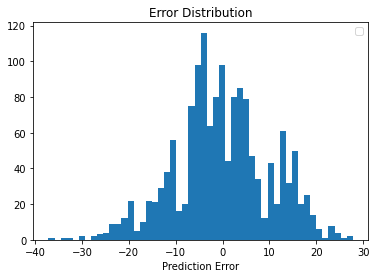

In [45]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [46]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Activity_Level_num 0.2866946559984242
FGC-FGC_CORE_CAL 0.2562038886445391
Basic_Demos-Sex 0.18256280340716144
Physical-BMI 0.1603726074036407
BIA-BIA_Frame_num 0.1141660445462345
Basic_Demos-Age 0.0
Physical-Weight 0.0
Physical-Height 0.0
BIA-BIA_DEE 0.0
BIA-BIA_Fat 0.0


## ** TARGET VARIABLE Fitness_Endurance-Max_Stage

In [189]:
df_Fitness_Endurance= df[[
'Physical-Weight',
#'FGC-FGC_CORE_CAL',
'Basic_Demos-Age', 
'Physical-Height',
#'Physical-MAP_CAL',
'Fitness_Endurance-Max_Stage',
'BIA-BIA_DEE',
        #"BIA-BIA_Activity_Level_num",
        #'BIA-BIA_Frame_num',
        #'BIA-BIA_Fat'
]]


In [190]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [191]:
df_Fitness_Endurance["Fitness_Endurance-Max_Stage"] = df_Fitness_Endurance["Fitness_Endurance-Max_Stage"].astype(int)

In [192]:
df_Fitness_Endurance=df_Fitness_Endurance[(df_Fitness_Endurance["Fitness_Endurance-Max_Stage"] >=3) & (df_Fitness_Endurance["Fitness_Endurance-Max_Stage"]<=8)]

In [193]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
Basic_Demos-Age                0
Physical-Height                0
Fitness_Endurance-Max_Stage    0
BIA-BIA_DEE                    0
dtype: int64

### Partitioning

In [194]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [195]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)


In [196]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3969, 4) (1324, 4) (3969,) (1324,)


In [197]:
df_Fitness_Endurance.shape

(5293, 5)

### Randomized Search

In [198]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [199]:
# param_list = {
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_Fitness_Endurance = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [200]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 20)),
#     'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['gini', 'entropy']
# }

# dt_reg_Fitness_Endurance = RandomForestClassifier(random_state=0)

# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=0), # Added random_state for reproducibility
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0),
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Good practice for RandomizedSearchCV
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [201]:
# param_list = {
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_Fitness_Endurance  = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance  = random_search.best_estimator_

In [202]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 20, 'max_depth': 9, 'criterion': 'entropy'} 0.6313864068788295


In [203]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_leaf=20,
                       min_samples_split=0.1)

In [204]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.629154078549849
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        41
           4       0.00      0.00      0.00       295
           5       0.63      1.00      0.77       835
           6       0.00      0.00      0.00       118
           7       0.00      0.00      0.00        29
           8       0.00      0.00      0.00         6

    accuracy                           0.63      1324
   macro avg       0.11      0.17      0.13      1324
weighted avg       0.40      0.63      0.49      1324



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [205]:
# y_pred = dt_reg_Fitness_Endurance.predict(X_test)

# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
# print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
# print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

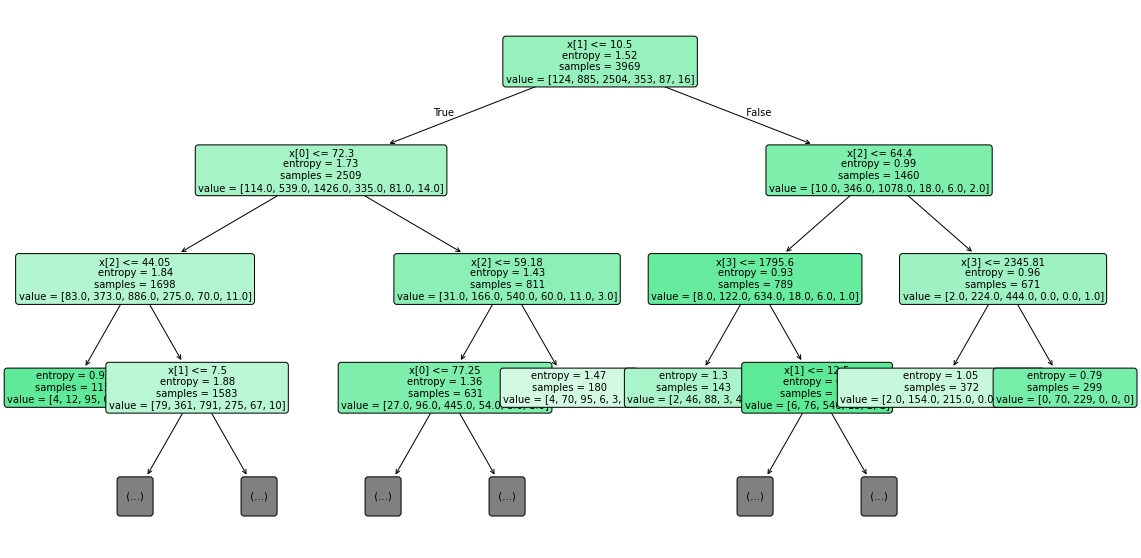

In [206]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1201 |  8.0000 |    5.0000 | 3.0000
  92 |  8.0000 |    5.0000 | 3.0000
 325 |  8.0000 |    5.0000 | 3.0000
  73 |  8.0000 |    5.0000 | 3.0000
  96 |  8.0000 |    5.0000 | 3.0000
 762 |  8.0000 |    5.0000 | 3.0000
 918 |  3.0000 |    5.0000 | 2.0000
 636 |  3.0000 |    5.0000 | 2.0000
 294 |  3.0000 |    5.0000 | 2.0000
1063 |  3.0000 |    5.0000 | 2.0000


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_967/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


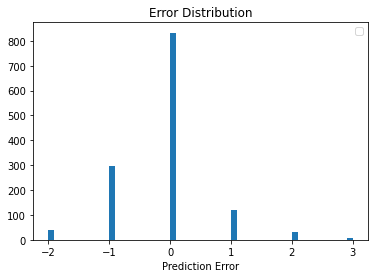

In [207]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [208]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.49892631757467343
Physical-Height 0.2505941029867695
Physical-Weight 0.13420198308578873
BIA-BIA_DEE 0.11627759635276821


## ** TARGET VARIABLE FGC-FGC_TL

In [328]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Weight',
'Physical-Height',
'BIA-BIA_TBW'
]]





In [329]:
df_FGC_TL=df_FGC_TL.dropna()

In [330]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
BIA-BIA_TBW         0
dtype: int64

### Partitioning

In [331]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [332]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [333]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5208, 8) (1736, 8) (5208,) (1736,)


In [334]:
df_FGC_TL.shape

(6944, 9)

### Randomized Search

In [335]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [336]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [337]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_FGC_TL = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_FGC_TL = random_search.best_estimator_

In [338]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 30, 'max_depth': 42, 'criterion': 'friedman_mse'} -5.714326214230198


In [339]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=42,
                      min_samples_leaf=30, min_samples_split=0.1)

In [340]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.4322
MAE  : 1.8049
MSE  : 5.9154
R²   : 0.1372


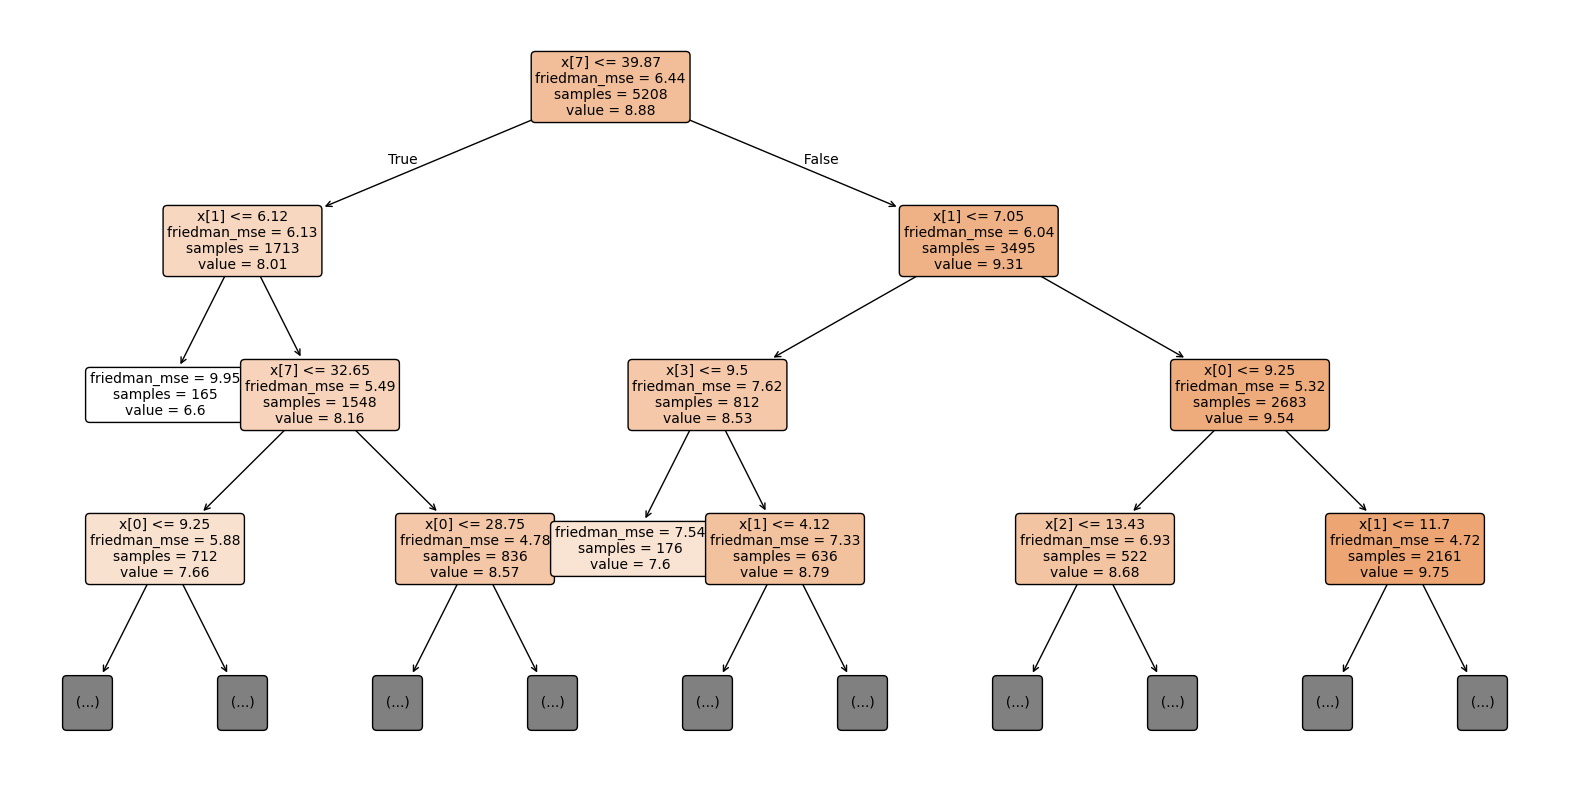

In [341]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1208 | 19.0000 |    7.6023 | 11.3977
1156 | 22.0000 |   11.0303 | 10.9697
 500 | 20.0000 |    9.5634 | 10.4366
 958 |  0.0000 |    9.4579 | 9.4579
1205 |  0.0000 |    9.3793 | 9.3793
1274 |  0.0000 |    8.2543 | 8.2543
 770 |  3.0000 |   11.0303 | 8.0303
1112 |  0.0000 |    7.9203 | 7.9203
1086 |  0.0000 |    7.9203 | 7.9203
 677 |  0.0000 |    7.3219 | 7.3219


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


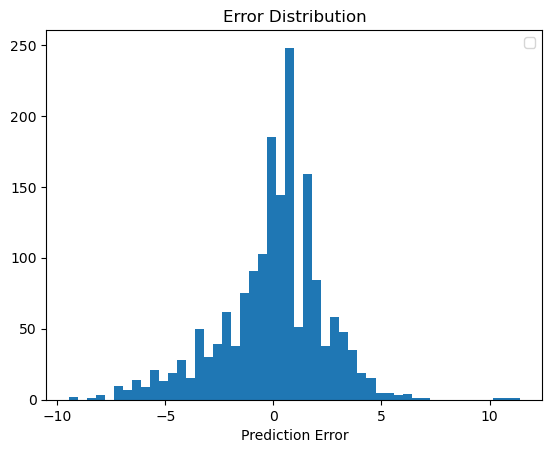

In [342]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [343]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_TBW 0.42623863416500135
FGC-FGC_SR_CAL 0.29871197293317014
FGC-FGC_CORE_CAL 0.16485901409391446
Physical-Weight 0.042893452957421196
Basic_Demos-Age 0.03657626369940084
BIA-BIA_ECW 0.030720662151091913
Basic_Demos-Sex 0.0
Physical-Height 0.0


## ** TARGET VARIABLE SDS-SDS_Total_T

In [ ]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height',
'BIA-BIA_FMI',
'BIA-BIA_DEE',
        "BIA-BIA_Activity_Level_num",
        'BIA-BIA_Frame_num',
        'BIA-BIA_Fat'
]]




In [174]:
df_SDS_Total=df_SDS_Total.dropna()

In [175]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T               0
Basic_Demos-Age               0
Basic_Demos-Sex               0
Physical-Weight               0
Physical-Height               0
BIA-BIA_FMI                   0
BIA-BIA_DEE                   0
BIA-BIA_Activity_Level_num    0
BIA-BIA_Frame_num             0
BIA-BIA_Fat                   0
dtype: int64

### Partitioning

In [176]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [178]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3677, 9) (1226, 9) (3677,) (1226,)


In [179]:
df_SDS_Total.shape

(4903, 10)

### Randomized Search

In [180]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [181]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [182]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_SDS_Total = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_SDS_Total = random_search.best_estimator_

In [183]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 150, 'max_depth': 21, 'criterion': 'squared_error'} -160.50744827759283


In [184]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=21, min_samples_leaf=150, min_samples_split=0.2)

In [185]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.6040
MAE  : 9.3769
MSE  : 158.8614
R²   : -0.0126


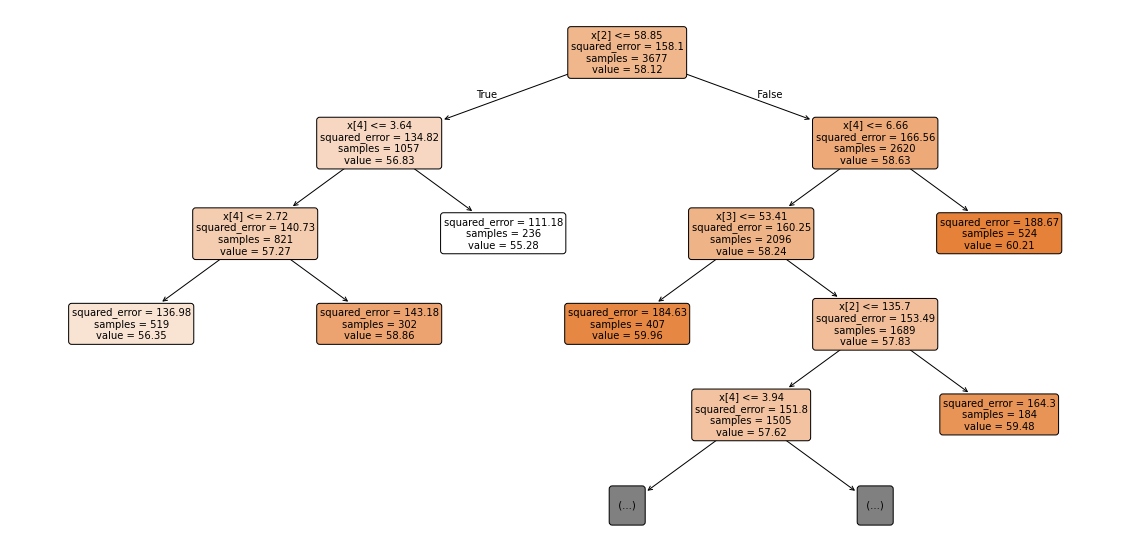

In [186]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 293 | 100.0000 |   55.2797 | 44.7203
 448 | 100.0000 |   56.3497 | 43.6503
 103 | 100.0000 |   56.3497 | 43.6503
 728 | 100.0000 |   56.3497 | 43.6503
 257 | 100.0000 |   56.3497 | 43.6503
 319 | 100.0000 |   56.7635 | 43.2365
 953 | 100.0000 |   56.7635 | 43.2365
1017 | 100.0000 |   56.7635 | 43.2365
 262 | 99.5000 |   56.3497 | 43.1503
 669 | 100.0000 |   57.2474 | 42.7526


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_967/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


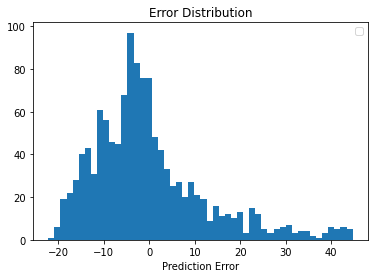

In [187]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [188]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.5153312705309249
Physical-Weight 0.32446591418908305
Physical-Height 0.16020281527999203
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
BIA-BIA_DEE 0.0
BIA-BIA_Activity_Level_num 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_Fat 0.0


## ** TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [ ]:
df_computerinternet= df[[
'Basic_Demos-Age', #'CGAS-CGAS_Score', 
       #'Physical-Height',
         'Physical-Weight',# 'BIA-BIA_BMR',
       #'Physical-HeartRate', #'FGC-FGC_TL',
       #'BIA-BIA_Frame_num',
        #'BIA-BIA_SMM',
        'BIA-BIA_Fat',
       'PreInt_EduHx-computerinternet_hoursday'
]]


In [44]:
df_computerinternet=df_computerinternet.dropna()

In [45]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
Physical-Weight                           0
Physical-HeartRate                        0
BIA-BIA_Frame_num                         0
BIA-BIA_Fat                               0
PreInt_EduHx-computerinternet_hoursday    0
dtype: int64

### Partitioning

In [46]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)


In [48]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5307, 5) (1770, 5) (5307,) (1770,)


In [49]:
df_computerinternet.shape

(7077, 6)

### Randomized Search

In [50]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [51]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_computerinternet = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_computerinternet = random_search.best_estimator_

In [52]:
# param_list = {
#     'max_depth': [None] + list(np.arange(10, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_computerinternet = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_computerinternet = random_search.best_estimator_

In [53]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 10, 'max_depth': 3, 'criterion': 'entropy'} 0.5168602267341864


In [54]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,
                       min_samples_split=0.1)

In [55]:
y_pred = dt_reg_computerinternet.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5101694915254237
              precision    recall  f1-score   support

         0.0       0.57      0.83      0.68       833
         1.0       0.00      0.00      0.00       308
         2.0       0.37      0.45      0.41       460
         3.0       0.00      0.00      0.00       169

    accuracy                           0.51      1770
   macro avg       0.24      0.32      0.27      1770
weighted avg       0.37      0.51      0.43      1770



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [56]:
# y_pred = dt_reg_computerinternet.predict(X_test)

# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
# print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
# print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

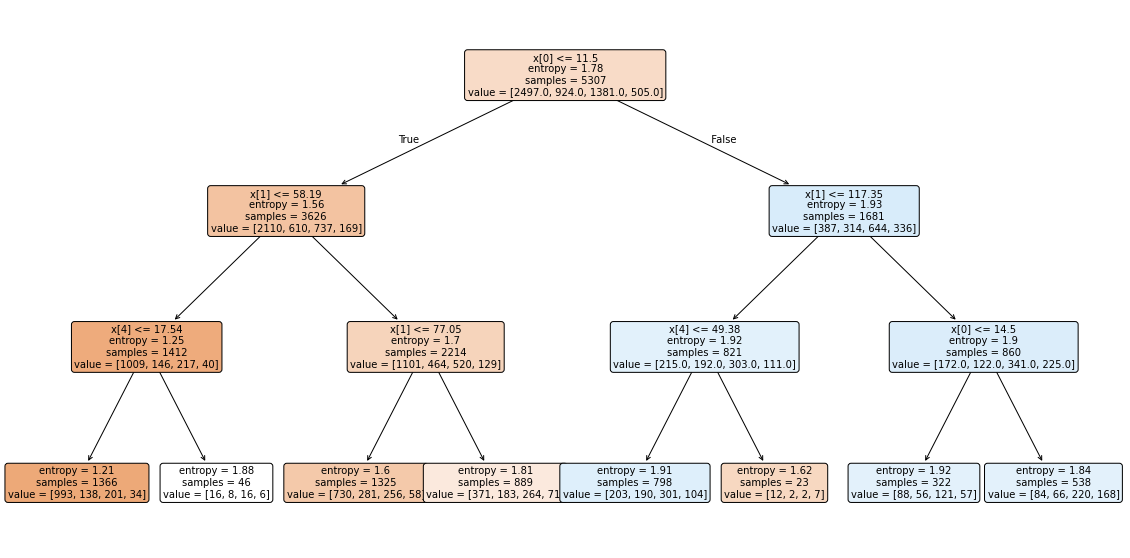

In [57]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1131 |  3.0000 |    0.0000 | 3.0000
 671 |  3.0000 |    0.0000 | 3.0000
1350 |  3.0000 |    0.0000 | 3.0000
 726 |  3.0000 |    0.0000 | 3.0000
 402 |  3.0000 |    0.0000 | 3.0000
1617 |  3.0000 |    0.0000 | 3.0000
 973 |  3.0000 |    0.0000 | 3.0000
1621 |  3.0000 |    0.0000 | 3.0000
  63 |  3.0000 |    0.0000 | 3.0000
1308 |  3.0000 |    0.0000 | 3.0000


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_1131/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


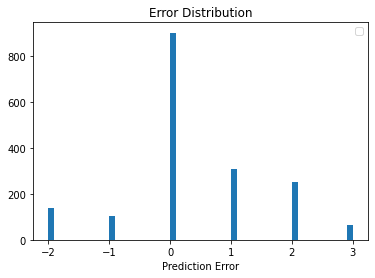

In [58]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [59]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.6915848094405134
Physical-Weight 0.2636972114608002
BIA-BIA_Fat 0.044717979098686376
Physical-HeartRate 0.0
BIA-BIA_Frame_num 0.0


# ** TARGET VARIABLE sii

In [530]:
df_sii= df[[
'Basic_Demos-Age', 'Basic_Demos-Sex',
#'CGAS-CGAS_Score',
'Physical-BMI',
       'Physical-Height', 'Physical-Weight',
       'BIA-BIA_BMR',
       #'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       #'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       #'BIA-BIA_ECW', 'BIA-BIA_ICW',
      'BIA-BIA_FFM',
       'BIA-BIA_FMI',
       
       'BIA-BIA_Fat',
       #'BIA-BIA_LST',
         'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW',
       #'SDS-SDS_Total_T',
       #'PreInt_EduHx-computerinternet_hoursday',
       'sii', #'Physical-MAP_CAL',
       #'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'
]]


In [531]:
#df_sii=df_sii[(df_sii['sii']!=0)]

In [ ]:
df_sii=df_sii.dropna()

(8459, 13)

### Partitioning

In [533]:
attributes = [col for col in df_sii.columns if col != 'sii']
X = df_sii[attributes].values
y = np.array(df_sii['sii'])

In [534]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)


In [535]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6344, 12) (2115, 12) (6344,) (2115,)


### Randomized Search

In [536]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [537]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_sii = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_sii = random_search.best_estimator_

In [538]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 20, 'max_depth': 4, 'criterion': 'gini'} 0.6901001310055609


In [539]:
dt_reg_sii = random_search.best_estimator_
dt_reg_sii.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                       min_samples_split=0.002)

In [540]:
y_pred = dt_reg_sii.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6846335697399527
              precision    recall  f1-score   support

         0.0       0.70      0.98      0.81      1458
         1.0       0.33      0.02      0.03       397
         2.0       0.18      0.02      0.04       238
         3.0       0.00      0.00      0.00        22

    accuracy                           0.68      2115
   macro avg       0.30      0.26      0.22      2115
weighted avg       0.56      0.68      0.57      2115



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Idx | Actual | Predicted | Error
----------------------------------------
2056 |  3.0000 |    0.0000 | 3.0000
1566 |  3.0000 |    0.0000 | 3.0000
 673 |  3.0000 |    0.0000 | 3.0000
1772 |  3.0000 |    0.0000 | 3.0000
1818 |  3.0000 |    0.0000 | 3.0000
2066 |  3.0000 |    0.0000 | 3.0000
 535 |  3.0000 |    0.0000 | 3.0000
1706 |  3.0000 |    0.0000 | 3.0000
1533 |  3.0000 |    0.0000 | 3.0000
  58 |  3.0000 |    0.0000 | 3.0000


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_1159/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


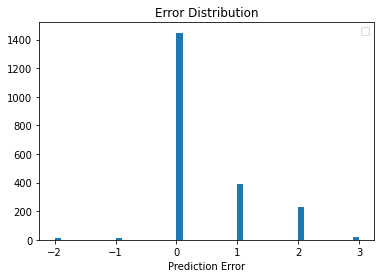

In [541]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [542]:
zipped = zip(attributes, dt_reg_sii.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.6037354668395446
Basic_Demos-Age 0.11509571519009643
BIA-BIA_FFM 0.07232589877624558
BIA-BIA_TBW 0.06481387764934976
Physical-Weight 0.052501666531528414
BIA-BIA_FMI 0.04335700964313413
Physical-BMI 0.03797818710932153
Basic_Demos-Sex 0.01019217826077945
BIA-BIA_BMR 0.0
BIA-BIA_Fat 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_SMM 0.0
